# Words and tokens: a companion notebook

**Human Language Technologies 2026-27, Lecture 02.** Claudio Gallicchio, University of Pisa.

This notebook lets you run the examples of the lecture and check the exercises of the exercise sheet. It follows Chapter 2 of Jurafsky and Martin, *Speech and Language Processing* (3rd edition draft, August 2026), sections 2.1 to 2.5.

1. Words: instances, types and Heaps' law
2. Unicode: code points, UTF-8 bytes, normalization
3. Byte-pair encoding: training and encoding, step by step
4. A real tokenizer: GPT-4o with `tiktoken` (optional)

How to use it: run the cells from top to bottom (Jupyter, VS Code or Google Colab). Only the Python standard library and `matplotlib` are needed. The two cells marked **Optional** need an internet connection the first time: one downloads a book, the other a tokenizer (`pip install tiktoken`). Change the inputs, break things, and look at what comes out: that is the point of the notebook.

## 1. Words: instances and types

The book's example sentence. How many words does it contain? The answer depends on two conventions: whether punctuation counts, and whether `The` and `the` are the same word. Real tokenizers use regular expressions; here `str.split` and a little punctuation stripping are enough.

In [1]:
from collections import Counter

SENTENCE = (
    "They picnicked by the pool, then lay back on the grass and looked at the stars."
)


def words(text, keep_punctuation=False, case_sensitive=True):
    """Split on whitespace; optionally separate punctuation into its own instances."""
    out = []
    for chunk in text.split():
        if not case_sensitive:
            chunk = chunk.lower()
        core = chunk.strip(".,;:!?\"'()")
        trailing = chunk[len(core) :] if chunk.endswith(tuple(".,;:!?\"')")) else ""
        if core:
            out.append(core)
        if keep_punctuation and trailing:
            out.extend(trailing)
    return out


for keep in (False, True):
    ws = words(SENTENCE, keep_punctuation=keep)
    print(
        f"punctuation {'kept' if keep else 'dropped'}: N = {len(ws):2d} instances, |V| = {len(set(ws)):2d} types"
    )
print()
print("instances:", words(SENTENCE))
print("types:    ", sorted(set(words(SENTENCE))))

punctuation dropped: N = 16 instances, |V| = 14 types
punctuation kept: N = 18 instances, |V| = 16 types

instances: ['They', 'picnicked', 'by', 'the', 'pool', 'then', 'lay', 'back', 'on', 'the', 'grass', 'and', 'looked', 'at', 'the', 'stars']
types:     ['They', 'and', 'at', 'back', 'by', 'grass', 'lay', 'looked', 'on', 'picnicked', 'pool', 'stars', 'the', 'then']


Sixteen instances without punctuation, eighteen with; fourteen types, because *the* occurs three times. Try the sentence of exercise 1 of the exercise sheet, with and without `case_sensitive`.

In [2]:
EXERCISE_1 = "The cat saw the other cat, and the other cat saw the dog."
for cs in (True, False):
    ws = words(EXERCISE_1, case_sensitive=cs)
    print(
        f"case sensitive = {cs!s:5}: N = {len(ws)}, |V| = {len(set(ws))}, types = {sorted(set(ws))}"
    )

case sensitive = True : N = 13, |V| = 7, types = ['The', 'and', 'cat', 'dog', 'other', 'saw', 'the']
case sensitive = False: N = 13, |V| = 6, types = ['and', 'cat', 'dog', 'other', 'saw', 'the']


### A small corpus and its frequent words

A real text, small enough to read: Lincoln's Gettysburg Address (1863, public domain; the dashes are written as hyphens here). The most frequent words of any English text are the short function words: articles, prepositions, pronouns.

In [3]:
GETTYSBURG = """Four score and seven years ago our fathers brought forth on this continent, a new nation,
conceived in Liberty, and dedicated to the proposition that all men are created equal.
Now we are engaged in a great civil war, testing whether that nation, or any nation so conceived and
so dedicated, can long endure. We are met on a great battle-field of that war. We have come to dedicate
a portion of that field, as a final resting place for those who here gave their lives that that nation
might live. It is altogether fitting and proper that we should do this.
But, in a larger sense, we can not dedicate - we can not consecrate - we can not hallow - this ground.
The brave men, living and dead, who struggled here, have consecrated it, far above our poor power to
add or detract. The world will little note, nor long remember what we say here, but it can never forget
what they did here. It is for us the living, rather, to be dedicated here to the unfinished work which
they who fought here have thus far so nobly advanced. It is rather for us to be here dedicated to the
great task remaining before us - that from these honored dead we take increased devotion to that cause
for which they gave the last full measure of devotion - that we here highly resolve that these dead
shall not have died in vain - that this nation, under God, shall have a new birth of freedom - and that
government of the people, by the people, for the people, shall not perish from the earth."""

tokens = [w for w in words(GETTYSBURG, case_sensitive=False) if w != "-"]
counts = Counter(tokens)
print(
    f"N = {len(tokens)} instances, |V| = {len(counts)} types, type/token ratio = {len(counts) / len(tokens):.2f}"
)
print()
for word, n in counts.most_common(12):
    print(f"{n:3d}  {word}")

N = 271 instances, |V| = 138 types, type/token ratio = 0.51

 13  that
 11  the
 10  we
  8  to
  8  here
  7  a
  6  and
  5  nation
  5  can
  5  of
  5  have
  5  for


### Heaps' law

The vocabulary grows with the size of the corpus as |V| = k N<sup>β</sup>. We can watch it happen: read the text word by word and record how many distinct types we have seen after N instances. On a log-log plot a power law is a straight line with slope β.

On a text this short we are still in the first regime of Figure 2.2 of the book: almost every word is new, and β is close to 1. On a whole book β drops to about 0.5 to 0.6.

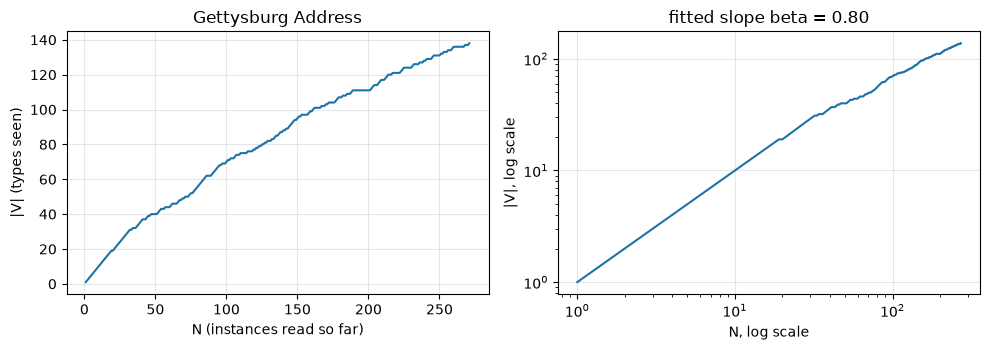

In [4]:
import math
import matplotlib.pyplot as plt


def vocabulary_growth(tokens):
    seen, growth = set(), []
    for w in tokens:
        seen.add(w)
        growth.append(len(seen))
    return growth


def fit_beta(growth):
    """least-squares slope of log|V| against log N"""
    xs = [math.log(n) for n in range(1, len(growth) + 1)]
    ys = [math.log(v) for v in growth]
    mx, my = sum(xs) / len(xs), sum(ys) / len(ys)
    return sum((x - mx) * (y - my) for x, y in zip(xs, ys)) / sum(
        (x - mx) ** 2 for x in xs
    )


def plot_growth(tokens, title):
    growth = vocabulary_growth(tokens)
    beta = fit_beta(growth)
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
    axes[0].plot(range(1, len(growth) + 1), growth, color="#1D73A6")
    axes[0].set_xlabel("N (instances read so far)")
    axes[0].set_ylabel("|V| (types seen)")
    axes[0].set_title(title)
    axes[1].loglog(range(1, len(growth) + 1), growth, color="#1D73A6")
    axes[1].set_xlabel("N, log scale")
    axes[1].set_ylabel("|V|, log scale")
    axes[1].set_title(f"fitted slope beta = {beta:.2f}")
    for ax in axes:
        ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    return beta


beta = plot_growth(tokens, "Gettysburg Address")

**Optional.** For the real curve, run the next cell: it downloads *Alice's Adventures in Wonderland* from Project Gutenberg (about 27,000 words) and repeats the plot. You can point `URL` to any plain-text book, or replace the download with a file of your own.

In [6]:
import urllib.request

URL = "https://www.gutenberg.org/files/11/11-0.txt"  # Alice's Adventures in Wonderland
raw = urllib.request.urlopen(URL, timeout=30).read().decode("utf-8")
body = raw.split("*** START OF")[1].split("*** END OF")[
    0
]  # strip the Gutenberg header and footer
book_tokens = words(body, case_sensitive=False)
print(f"N = {len(book_tokens)}, |V| = {len(set(book_tokens))}")
beta_book = plot_growth(book_tokens, "Alice's Adventures in Wonderland")
print("most frequent:", Counter(book_tokens).most_common(10))

URLError: <urlopen error [Errno 111] Connection refused>

## 2. Unicode

A Python `str` is a sequence of **code points**, the unique numbers Unicode assigns to characters, written `U+` followed by hexadecimal digits. A file, instead, is a sequence of **bytes**, and needs an encoding, almost always UTF-8.

In [ ]:
import unicodedata

for ch in "aé进😀":
    print(f"{ch!r:6} U+{ord(ch):04X}  {unicodedata.name(ch)}")

'a'    U+0061  LATIN SMALL LETTER A
'é'    U+00E9  LATIN SMALL LETTER E WITH ACUTE
'进'    U+8FDB  CJK UNIFIED IDEOGRAPH-8FDB
'😀'    U+1F600  GRINNING FACE


In [ ]:
for s in ["café", "日本", "😀", "naïve"]:
    b = s.encode("utf-8")
    print(f"{s!r:10} {len(s)} code points, {len(b)} bytes: {b.hex(' ').upper()}")

'café'     4 code points, 5 bytes: 63 61 66 C3 A9
'日本'       2 code points, 6 bytes: E6 97 A5 E6 9C AC
'😀'        1 code points, 4 bytes: F0 9F 98 80
'naïve'    5 code points, 6 bytes: 6E 61 C3 AF 76 65


### UTF-8 by hand

Figure 2.5 of the book gives the recipe: the code point range decides how many bytes are used; the first byte announces the length with its leading bits, continuation bytes start with `10`, and the bits of the code point fill the free slots. The function below prints every step, so you can check exercise 5 of the sheet (é, U+00E9, and 进, U+8FDB) and the book's own example (ñ, U+00F1).

In [ ]:
ROWS = [  # (last code point of the range, template): x = payload bit
    (0x7F, "0xxxxxxx"),
    (0x7FF, "110xxxxx 10xxxxxx"),
    (0xFFFF, "1110xxxx 10xxxxxx 10xxxxxx"),
    (0x10FFFF, "11110xxx 10xxxxxx 10xxxxxx 10xxxxxx"),
]


def utf8_by_hand(ch):
    cp = ord(ch)
    template = next(t for last, t in ROWS if cp <= last)
    n_bits = template.count("x")
    bits = format(cp, f"0{n_bits}b")  # the code point on exactly the available bits
    it = iter(bits)
    encoded = "".join(next(it) if c == "x" else c for c in template)
    byte_values = [int(b, 2) for b in encoded.split()]
    print(f"{ch}  U+{cp:04X}  = {cp:b} in binary")
    print(f"  row:      {template}")
    print(f"  payload:  {bits}  ({n_bits} bits, zero-padded on the left)")
    print(f"  bytes:    {encoded}")
    print(
        f"  hex:      {' '.join(f'{b:02X}' for b in byte_values)}   Python agrees: {ch.encode('utf-8').hex(' ').upper()}"
    )
    print()


for ch in "ñé进😀":
    utf8_by_hand(ch)

ñ  U+00F1  = 11110001 in binary
  row:      110xxxxx 10xxxxxx
  payload:  00011110001  (11 bits, zero-padded on the left)
  bytes:    11000011 10110001
  hex:      C3 B1   Python agrees: C3 B1

é  U+00E9  = 11101001 in binary
  row:      110xxxxx 10xxxxxx
  payload:  00011101001  (11 bits, zero-padded on the left)
  bytes:    11000011 10101001
  hex:      C3 A9   Python agrees: C3 A9

进  U+8FDB  = 1000111111011011 in binary
  row:      1110xxxx 10xxxxxx 10xxxxxx
  payload:  1000111111011011  (16 bits, zero-padded on the left)
  bytes:    11101000 10111111 10011011
  hex:      E8 BF 9B   Python agrees: E8 BF 9B

😀  U+1F600  = 11111011000000000 in binary
  row:      11110xxx 10xxxxxx 10xxxxxx 10xxxxxx
  payload:  000011111011000000000  (21 bits, zero-padded on the left)
  bytes:    11110000 10011111 10011000 10000000
  hex:      F0 9F 98 80   Python agrees: F0 9F 98 80



### Reading bytes

Going the other way: the first bits of each byte tell you where characters start and how long they are, before you decode anything. This is what makes UTF-8 self-synchronizing. Exercise 6 of the sheet uses these sequences.

In [ ]:
def byte_role(b):
    if b < 0x80:
        return "1-byte character (ASCII)"
    if b < 0xC0:
        return "continuation byte (10......)"
    if b < 0xE0:
        return "start of a 2-byte character (110.....)"
    if b < 0xF0:
        return "start of a 3-byte character (1110....)"
    return "start of a 4-byte character (11110...)"


for hexs in ["E2 82 AC", "C3 B1 6F 6C 61", "68 65 6C 6C 6F", "F0 9F 98 80 21"]:
    b = bytes.fromhex(hexs)
    print(hexs, "->", repr(b.decode("utf-8")), f"({len(b.decode('utf-8'))} characters)")
    for x in b:
        print(f"    {x:02X} = {x:08b}  {byte_role(x)}")

E2 82 AC -> '€' (1 characters)
    E2 = 11100010  start of a 3-byte character (1110....)
    82 = 10000010  continuation byte (10......)
    AC = 10101100  continuation byte (10......)
C3 B1 6F 6C 61 -> 'ñola' (4 characters)
    C3 = 11000011  start of a 2-byte character (110.....)
    B1 = 10110001  continuation byte (10......)
    6F = 01101111  1-byte character (ASCII)
    6C = 01101100  1-byte character (ASCII)
    61 = 01100001  1-byte character (ASCII)
68 65 6C 6C 6F -> 'hello' (5 characters)
    68 = 01101000  1-byte character (ASCII)
    65 = 01100101  1-byte character (ASCII)
    6C = 01101100  1-byte character (ASCII)
    6C = 01101100  1-byte character (ASCII)
    6F = 01101111  1-byte character (ASCII)
F0 9F 98 80 21 -> '😀!' (2 characters)
    F0 = 11110000  start of a 4-byte character (11110...)
    9F = 10011111  continuation byte (10......)
    98 = 10011000  continuation byte (10......)
    80 = 10000000  continuation byte (10......)
    21 = 00100001  1-byte character 

### There is no text file without an encoding

Decoding bytes with the wrong encoding does not fail, it produces *mojibake*. Always say which encoding you mean when you open a file.

In [ ]:
data = "café".encode("utf-8")
print("as utf-8: ", data.decode("utf-8"))
print(
    "as latin-1:",
    data.decode("latin-1"),
    "   <- the two bytes of é read as two Latin-1 characters",
)

with open("demo.txt", "w", encoding="utf-8") as f:
    f.write("Señor, respondió")
with open("demo.txt", "rb") as f:
    print("on disk:  ", f.read().hex(" ").upper())
with open("demo.txt", encoding="utf-8") as f:
    print("read back:", f.read())

as utf-8:  café
as latin-1: cafÃ©    <- the two bytes of é read as two Latin-1 characters
on disk:   53 65 C3 B1 6F 72 2C 20 72 65 73 70 6F 6E 64 69 C3 B3
read back: Señor, respondió


### Same appearance, different code points

`é` can be one code point (U+00E9) or `e` followed by the combining acute accent (U+0301). The two strings look identical and compare unequal; for a tokenizer they are different inputs. Unicode normalization (NFC composes, NFD decomposes) makes them equal. A pretrained tokenizer expects the normalization it was trained with.

In [ ]:
a = "café"
b = "café"
print(
    a,
    b,
    "| equal:",
    a == b,
    "| code points:",
    len(a),
    len(b),
    "| bytes:",
    len(a.encode()),
    len(b.encode()),
)
print(
    "NFC:",
    unicodedata.normalize("NFC", a) == unicodedata.normalize("NFC", b),
    "| NFD:",
    unicodedata.normalize("NFD", a) == unicodedata.normalize("NFD", b),
)
print([f"U+{ord(c):04X}" for c in unicodedata.normalize("NFD", a)])

café café | equal: False | code points: 4 5 | bytes: 5 6
NFC: True | NFD: True
['U+0063', 'U+0061', 'U+0066', 'U+0065', 'U+0301']


## 3. Byte-pair encoding

BPE learns a vocabulary from data. Training (Figure 2.6 of the book): start from the characters, count adjacent pairs of tokens across the corpus (weighted by word frequency), merge the most frequent pair into a new token, repeat *k* times. In practice merges stay inside words: the corpus is first split into words, each with a leading space, written `_` here.

The implementation below prints the corpus after every merge, so you can follow the book's worked example (corpus `set new new renew reset renew`, Figures 2.7 and following) and check exercise 7 of the sheet.

In [ ]:
from collections import Counter


def pair_counts(corpus):
    """corpus: {tuple_of_tokens: count}. Adjacent pairs, weighted by word frequency."""
    counts = Counter()
    for toks, n in corpus.items():
        for a, b in zip(toks, toks[1:]):
            counts[(a, b)] += n
    return counts


def merge(toks, pair):
    """replace every adjacent occurrence of pair by the merged token, left to right"""
    out, i = [], 0
    while i < len(toks):
        if i < len(toks) - 1 and (toks[i], toks[i + 1]) == pair:
            out.append(toks[i] + toks[i + 1])
            i += 2
        else:
            out.append(toks[i])
            i += 1
    return out


def train_bpe(word_counts, k, verbose=True):
    corpus = {tuple(w): n for w, n in word_counts.items()}
    vocab = sorted({ch for w in corpus for ch in w})
    merges = []
    if verbose:
        print(f"start: vocabulary {vocab} ({len(vocab)} symbols)")
        show(corpus)
    for step in range(1, k + 1):
        counts = pair_counts(corpus)
        if not counts:
            break
        (a, b), n = counts.most_common(1)[0]  # ties: the first pair found in the corpus
        merges.append((a, b))
        vocab.append(a + b)
        corpus = {tuple(merge(list(t), (a, b))): c for t, c in corpus.items()}
        if verbose:
            runners = ", ".join(
                f"{x}{y} {c}" for (x, y), c in counts.most_common(4)[1:]
            )
            print(f"merge {step}: {a} {b} -> {a + b}  (count {n}; next: {runners})")
            show(corpus)
    return vocab, merges


def show(corpus):
    for toks, n in corpus.items():
        print(f"     {n} x {' '.join(toks)}")


BOOK_CORPUS = {
    "_new": 2,
    "_renew": 2,
    "set": 1,
    "_reset": 1,
}  # set new new renew reset renew
vocab, merges = train_bpe(BOOK_CORPUS, k=8)
print("\nvocabulary after 8 merges:", vocab, f"({len(vocab)} tokens)")
print("merges, in order:", merges)

start: vocabulary ['_', 'e', 'n', 'r', 's', 't', 'w'] (7 symbols)
     2 x _ n e w
     2 x _ r e n e w
     1 x s e t
     1 x _ r e s e t
merge 1: n e -> ne  (count 4; next: ew 4, _r 3, re 3)
     2 x _ ne w
     2 x _ r e ne w
     1 x s e t
     1 x _ r e s e t
merge 2: ne w -> new  (count 4; next: _r 3, re 3, _ne 2)
     2 x _ new
     2 x _ r e new
     1 x s e t
     1 x _ r e s e t
merge 3: _ r -> _r  (count 3; next: re 3, _new 2, enew 2)
     2 x _ new
     2 x _r e new
     1 x s e t
     1 x _r e s e t
merge 4: _r e -> _re  (count 3; next: _new 2, enew 2, se 2)
     2 x _ new
     2 x _re new
     1 x s e t
     1 x _re s e t
merge 5: _ new -> _new  (count 2; next: _renew 2, se 2, et 2)
     2 x _new
     2 x _re new
     1 x s e t
     1 x _re s e t
merge 6: _re new -> _renew  (count 2; next: se 2, et 2, _res 1)
     2 x _new
     2 x _renew
     1 x s e t
     1 x _re s e t
merge 7: s e -> se  (count 2; next: et 2, _res 1)
     2 x _new
     2 x _renew
     1 x se t
     1

The merges are the book's: `n e`, `ne w`, `_ r`, `_r e`, `_ new`, `_re new`, `s e`, `se t`. Note the word-initial prefix `_re`, induced from frequencies alone.

### The encoder

Encoding a new word applies the merges in the order they were learned, greedily; the frequencies in the new text play no role. The unknown-word problem is gone: a word no merge applies to is simply spelled out in characters.

In [ ]:
def encode(word, merges):
    toks = list(word)
    for pair in merges:
        toks = merge(toks, pair)
    return toks


for w in ["_newer", "_renewest", "_lower", "_reset", "_new", "new"]:
    print(f"{w:12} -> {encode(w, merges)}")

_newer       -> ['_new', 'e', 'r']
_renewest    -> ['_renew', 'e', 's', 't']
_lower       -> ['_', 'l', 'o', 'w', 'e', 'r']
_reset       -> ['_re', 'set']
_new         -> ['_new']
new          -> ['new']


### The corpus of exercise 7

Five words with their counts; the exercise asks for the first three merges, the vocabulary size, and the encoding of `_bug` and `_pun`.

In [ ]:
EXERCISE_7 = {"_hug": 10, "_pug": 5, "_pun": 12, "_bun": 4, "_hugs": 5}
vocab7, merges7 = train_bpe(EXERCISE_7, k=3)
print("\nvocabulary size:", len(vocab7))
for w in ["_bug", "_pun", "_hugs", "_bugs"]:
    print(f"{w:8} -> {encode(w, merges7)}")

start: vocabulary ['_', 'b', 'g', 'h', 'n', 'p', 's', 'u'] (8 symbols)
     10 x _ h u g
     5 x _ p u g
     12 x _ p u n
     4 x _ b u n
     5 x _ h u g s
merge 1: u g -> ug  (count 20; next: _p 17, pu 17, un 16)
     10 x _ h ug
     5 x _ p ug
     12 x _ p u n
     4 x _ b u n
     5 x _ h ug s
merge 2: _ p -> _p  (count 17; next: un 16, _h 15, hug 15)
     10 x _ h ug
     5 x _p ug
     12 x _p u n
     4 x _ b u n
     5 x _ h ug s
merge 3: u n -> un  (count 16; next: _h 15, hug 15, _pu 12)
     10 x _ h ug
     5 x _p ug
     12 x _p un
     4 x _ b un
     5 x _ h ug s

vocabulary size: 11
_bug     -> ['_', 'b', 'ug']
_pun     -> ['_p', 'un']
_hugs    -> ['_', 'h', 'ug', 's']
_bugs    -> ['_', 'b', 'ug', 's']


### Your own corpus

Feed a few sentences to the trainer and watch word-like tokens appear. Below: the Gettysburg Address, 60 merges, no printing. Change the text or *k* and look at the vocabulary and at how a new sentence is encoded.

In [ ]:
def word_counts(text):
    """words with a leading _ (the space), lower case, punctuation dropped"""
    return Counter("_" + w for w in words(text, case_sensitive=False) if w != "-")


vocab_g, merges_g = train_bpe(word_counts(GETTYSBURG), k=60, verbose=False)
print("last learned tokens:", vocab_g[-20:])
test = "the nation dedicated to freedom and to the people"
print([tok for w in word_counts(test) for tok in encode(w, merges_g)])

last learned tokens: ['me', 'se', '_and', '_ded', '_dedic', '_dedicat', 'ing', '_ca', '_not', '_de', 'her', '_con', '_nat', '_nation', 'iv', '_in', 'op', '_can', 'le', '_o']
['_the', '_nation', '_dedicat', 'ed', '_to', '_f', 're', 'ed', 'o', 'm', '_and', '_p', 'e', 'op', 'le']


## 4. A real tokenizer (optional)

The tokenizer of GPT-4o is a BPE with about 200,000 tokens, run on UTF-8 bytes after a regular-expression pre-tokenization. The `tiktoken` library gives you the same tokenizer that the online tool at tiktokenizer.vercel.app shows. Install it with `pip install tiktoken`; the first call downloads the vocabulary (a few MB).

Things to look at, all discussed in the lecture: most English words are one token including the leading space; `Anyhow` at the start of a sentence is two tokens, ` anyhow` after a space is one; numbers are cut into groups of three digits; a sentence in Italian takes more tokens than its English translation, because the training data is dominated by English.

In [ ]:
# if needed install tiktoken
#!pip install tiktoken

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 906.8/906.8 kB 21.0 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 284.6/284.6 kB 29.8 MB/s eta 0:00:00


In [ ]:
import tiktoken
from IPython.display import HTML, display

enc = tiktoken.get_encoding("o200k_base")  # GPT-4o

PALETTE = ["#DDE9F3", "#E8F7F6", "#FFF0ED", "#F3EBDD", "#EAE4F5"]


def show_tokens(text):
    ids = enc.encode(text)
    pieces = [enc.decode([i]) for i in ids]
    spans = "".join(
        f'<span style="background:{PALETTE[k % 5]};padding:2px 1px;border-radius:3px;font-family:Courier New">'
        f"{p.replace(' ', '&#9251;')}</span>"
        for k, p in enumerate(pieces)
    )
    display(
        HTML(
            f'<div style="font-size:16px;line-height:1.9">{spans}<span style="color:#596675;font-family:Arial"> &nbsp; {len(ids)} tokens</span></div>'
        )
    )
    return ids


show_tokens("Anyhow, Jane's dog said she's 224123 years old, anyhow.")
show_tokens("The committee postponed the decision until the following week.")
show_tokens("Il comitato ha rinviato la decisione alla settimana successiva.")
show_tokens("1234567890123 and https://web.stanford.edu/~jurafsky/slp3/ and C6H12O6")

[7633,
 19354,
 29338,
 19267,
 18,
 326,
 5918,
 1684,
 4116,
 1980,
 270,
 9201,
 21819,
 116705,
 51869,
 1553,
 38316,
 113852,
 79,
 18,
 14,
 326,
 363,
 21,
 39,
 899,
 46,
 21]

A token is really an integer id; `enc.encode` returns the ids and `enc.decode` turns them back into text. Try a paragraph of your own in two languages and compare the counts; then do exercise 11 of the sheet on the website.

## 5. What to do next

- The exercise sheet of this lecture: exercises 1, 4, 5, 6, 7 and 8 can be checked with the functions above (`words`, `utf8_by_hand`, `byte_role`, `train_bpe`, `encode`); exercise 11 uses the online tokenizer.
- Textbook exercises 2.1 to 2.3 (Chapter 2).
- Change the inputs: your own sentences, your own corpus for BPE, a book of your choice for Heaps' law.